In [43]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [44]:
df = pd.read_csv("Loan_default.csv")

In [45]:
print(df.shape)

print(df.columns)

print(df.info())

print(df.head())

(255347, 18)
Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Educatio

In [46]:
df.drop("LoanID", axis=1, inplace=True)

In [47]:
print(df.isnull().sum())

Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64


In [48]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [49]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [50]:
print(df.duplicated().sum())

0


In [51]:
df.drop_duplicates(inplace=True)

In [52]:
df = pd.get_dummies(df, drop_first=True)

In [53]:
X = df.drop("Default", axis=1)

y = df["Default"]

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

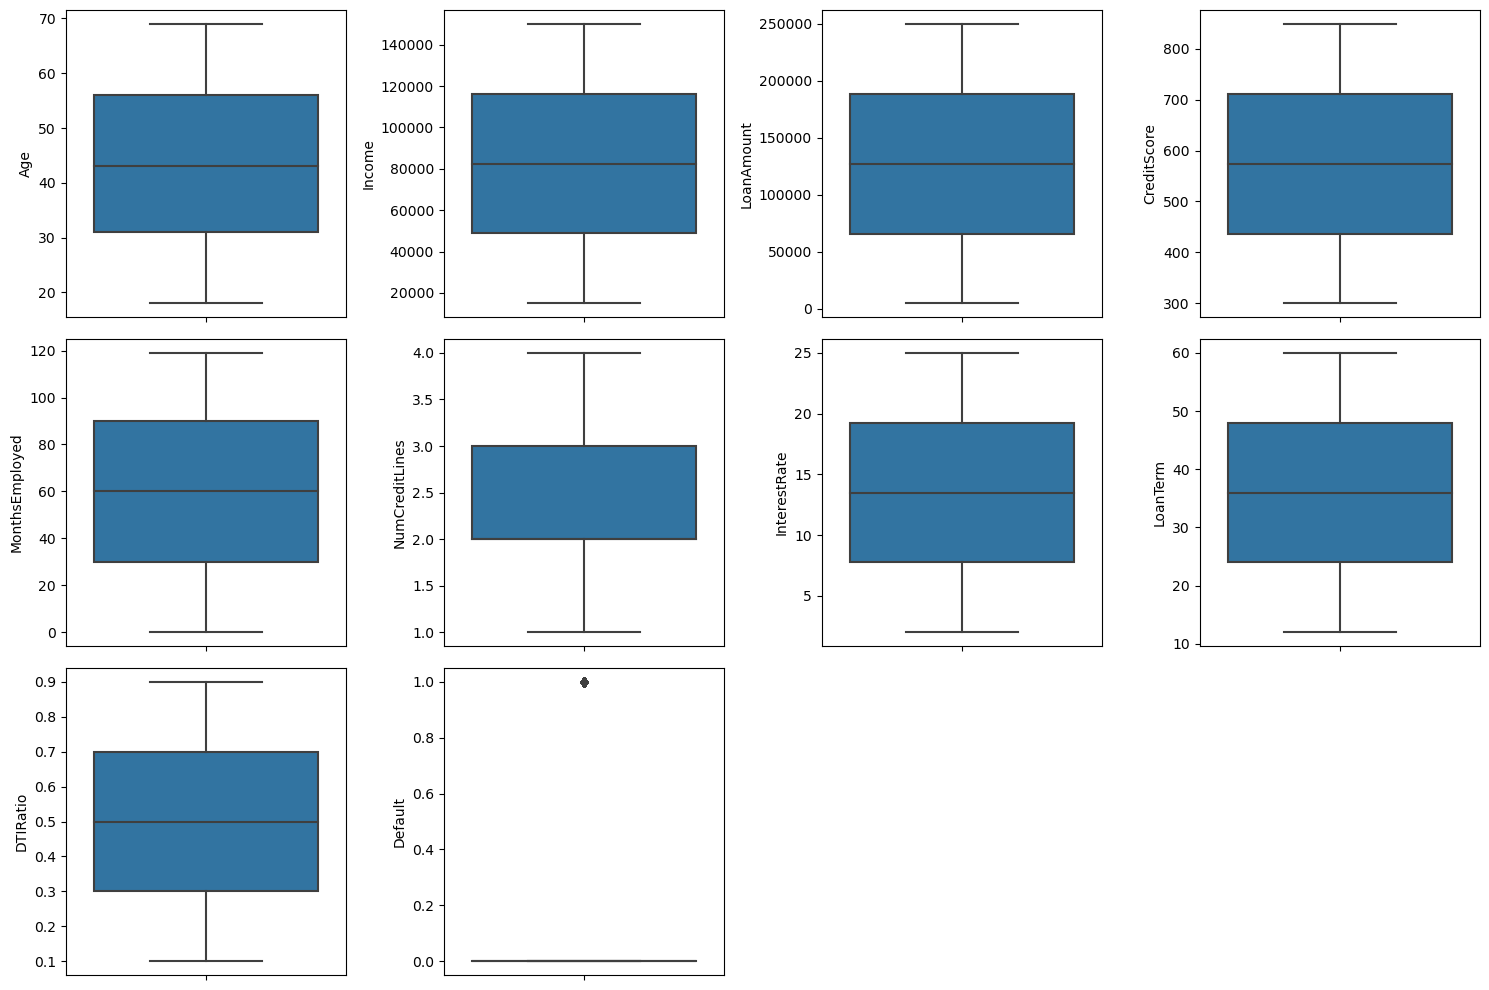

In [55]:
plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols):
    plt.subplot(3,4,i+1)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

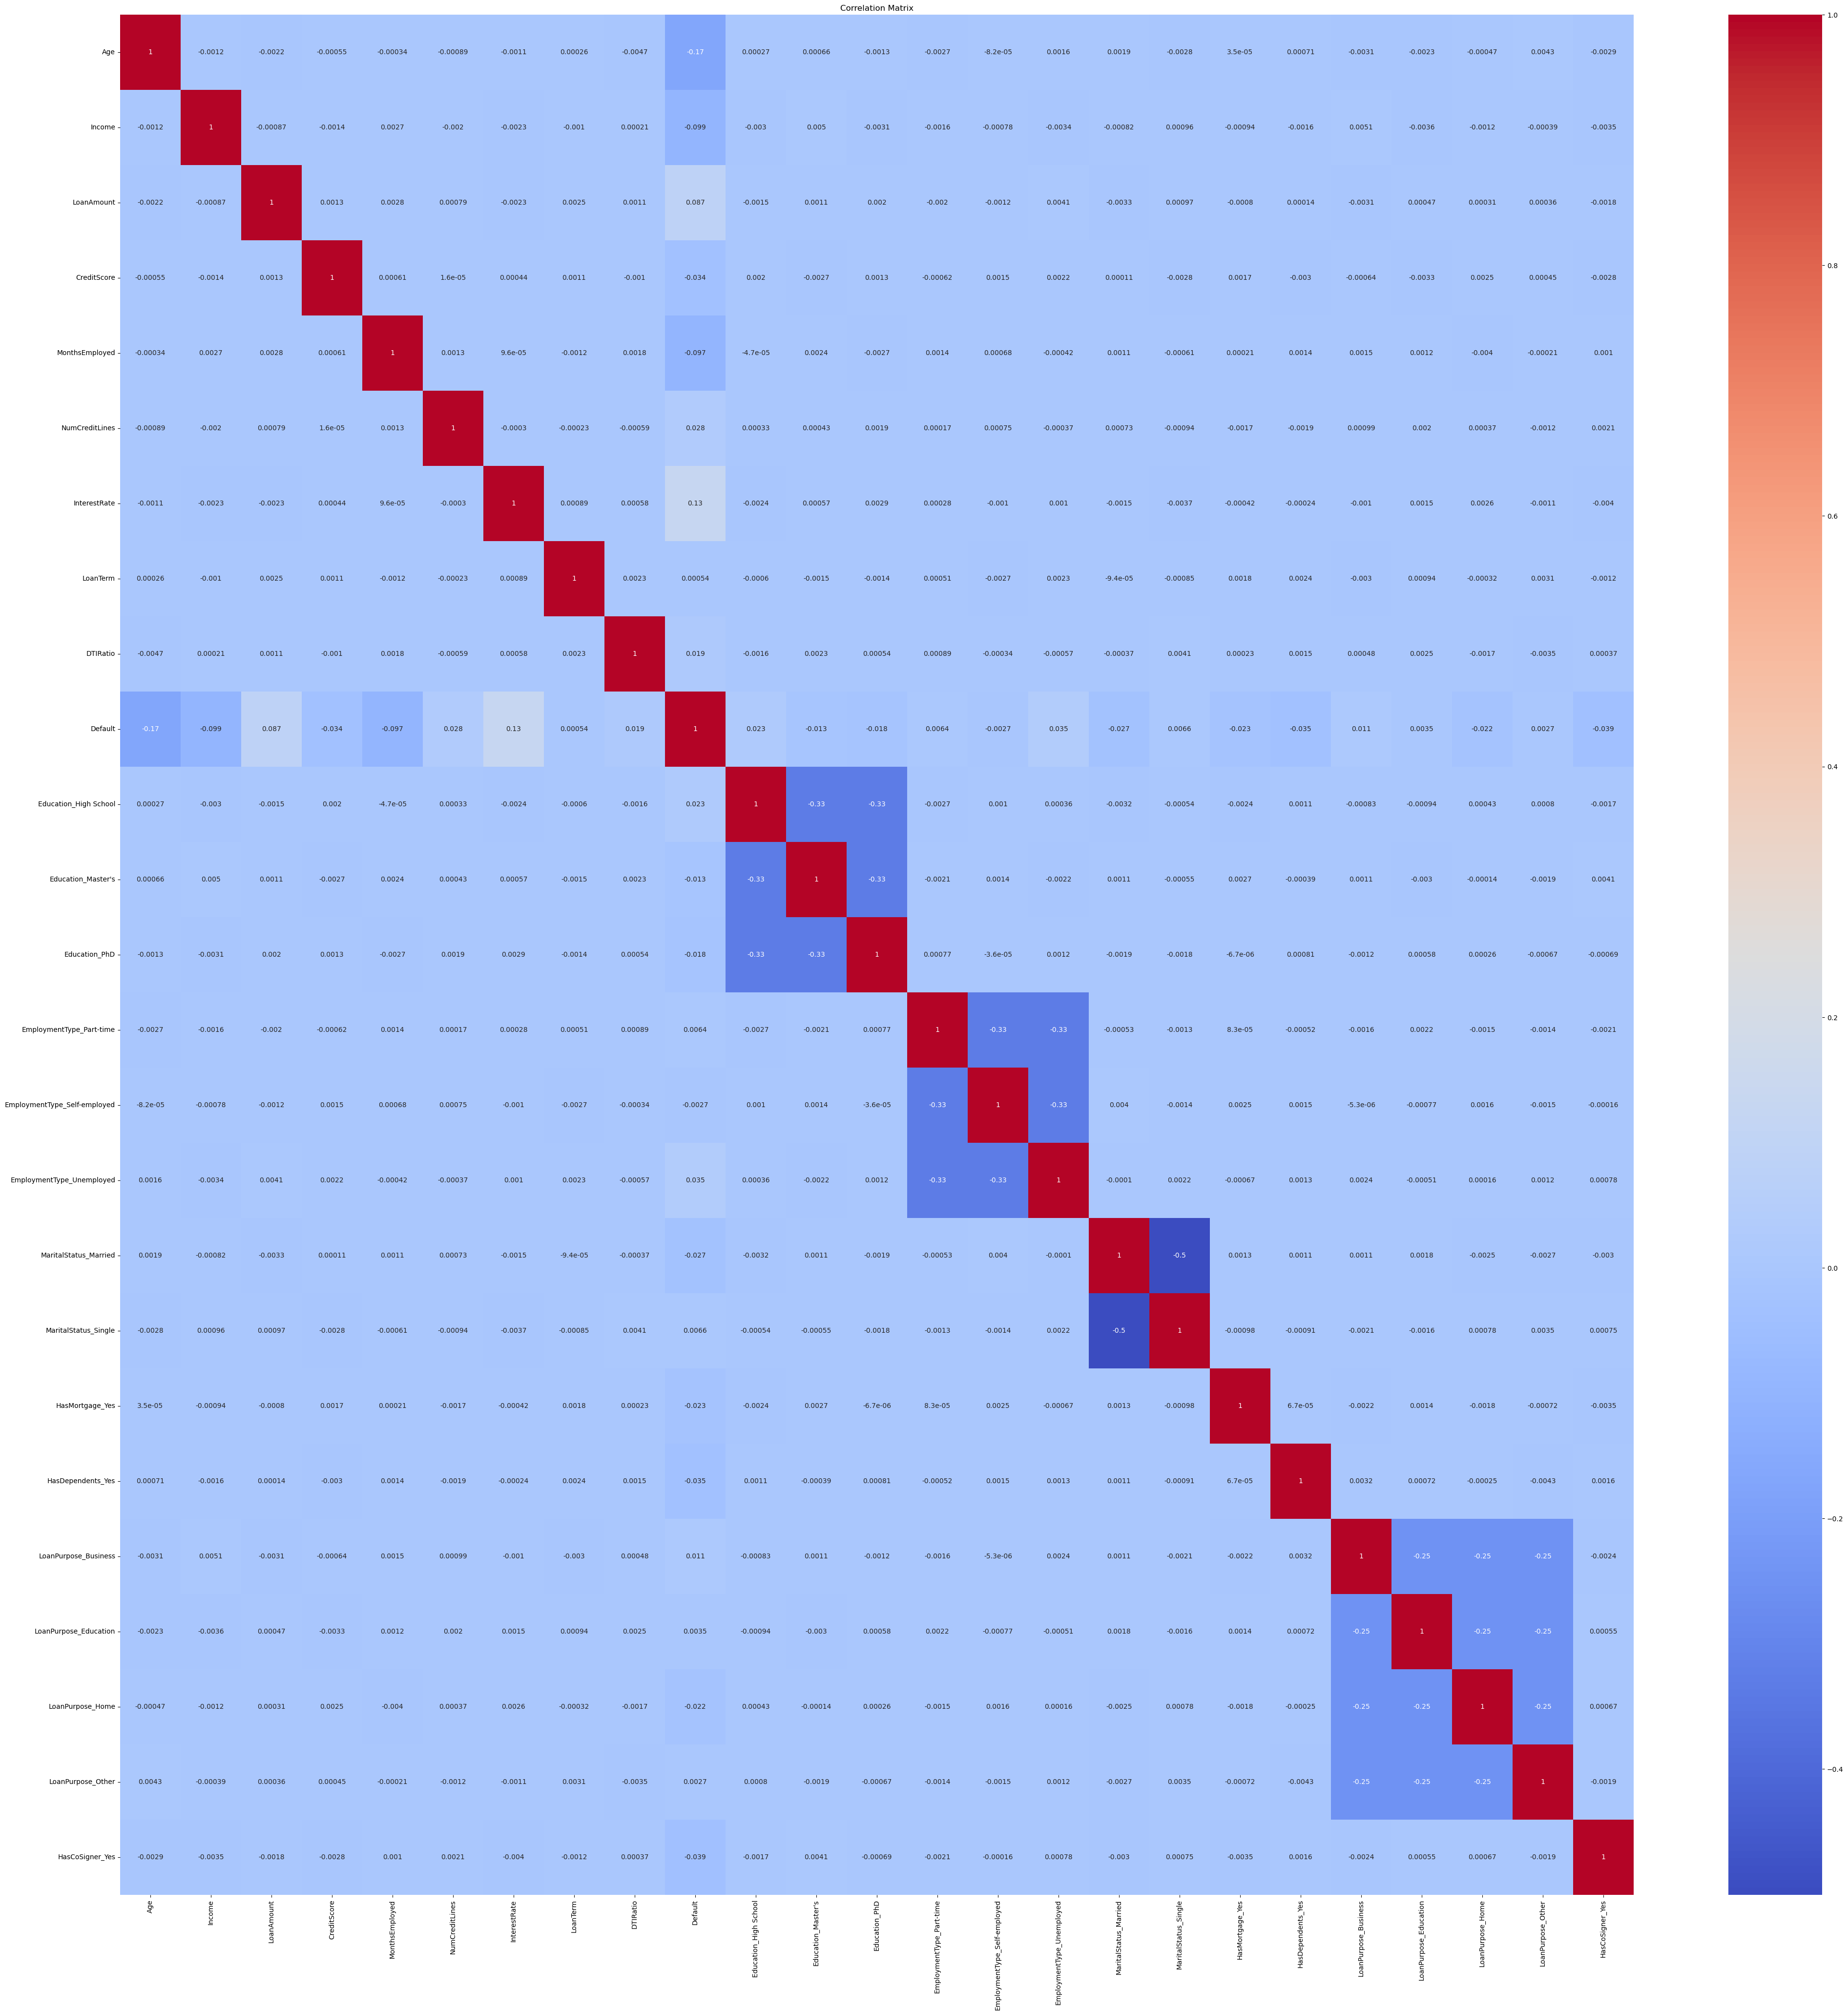

In [56]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(50,50))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [57]:
cat_cols = df.select_dtypes(include='object').columns
print(cat_cols)

Index([], dtype='object')


In [58]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(f"{col} Distribution")
    plt.show()

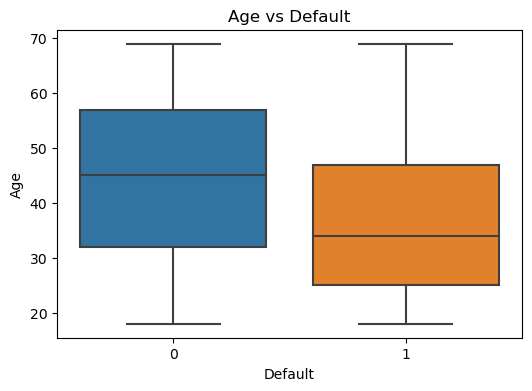

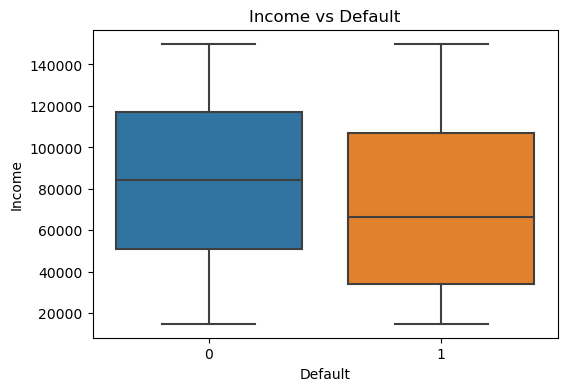

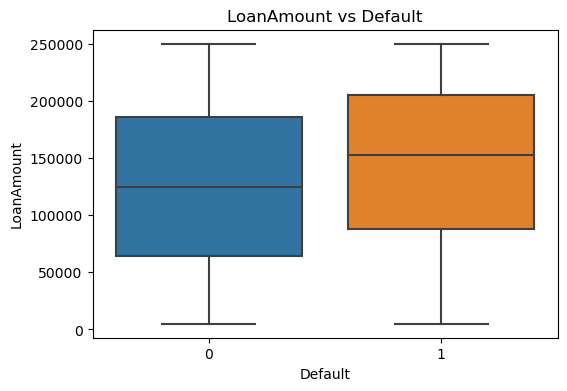

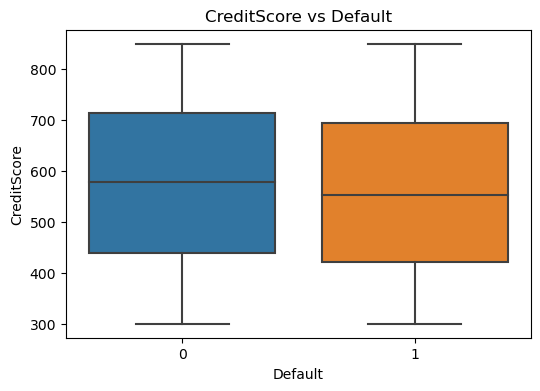

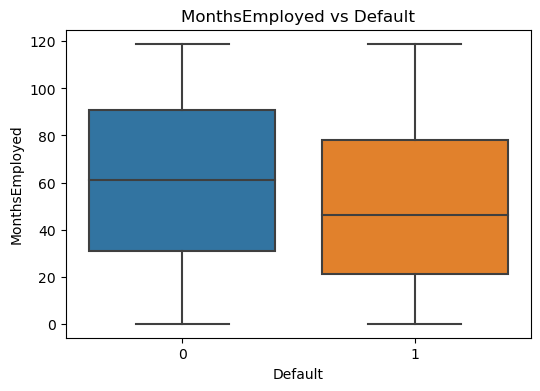

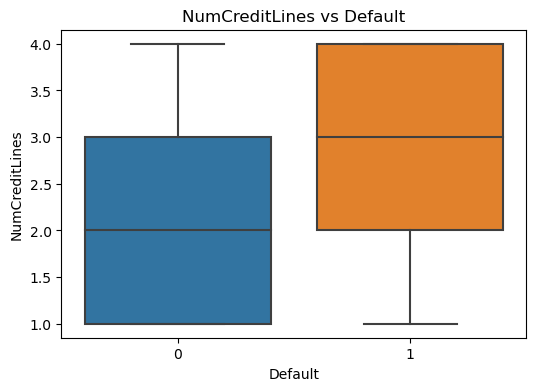

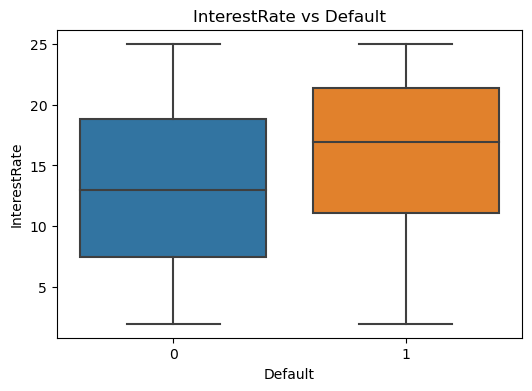

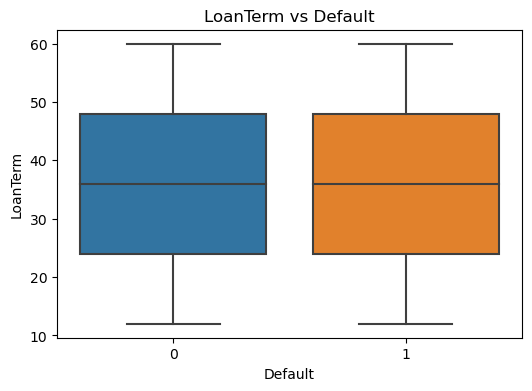

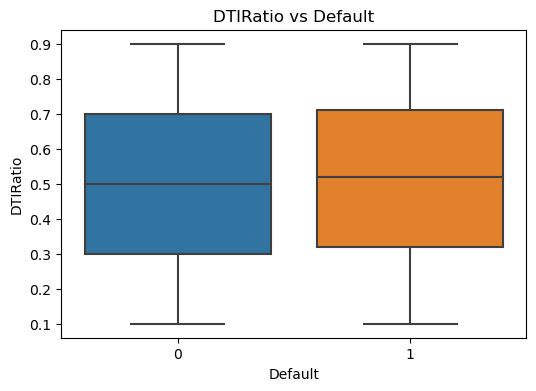

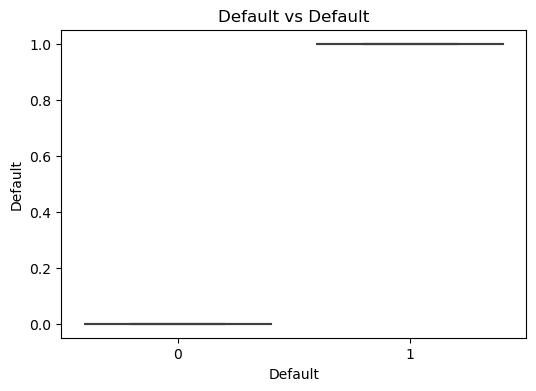

In [59]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Default', y=col, data=df)
    plt.title(f"{col} vs Default")
    plt.show()

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [63]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [64]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [66]:
lr_pred = lr_model.predict(X_test_scaled)

In [67]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [68]:
dt_pred = dt_model.predict(X_test)

In [69]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [70]:
rf_pred = rf_model.predict(X_test)

In [71]:
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.885275112590562
Decision Tree Accuracy: 0.8848834932445663
Random Forest Accuracy: 0.8853338554924614


In [72]:
print("Logistic Regression Report")
print(classification_report(y_test, lr_pred))

print("Decision Tree Report")
print(classification_report(y_test, dt_pred))

print("Random Forest Report")
print(classification_report(y_test, rf_pred))

Logistic Regression Report
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.61      0.03      0.06      5931

    accuracy                           0.89     51070
   macro avg       0.75      0.52      0.50     51070
weighted avg       0.85      0.89      0.84     51070

Decision Tree Report
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.63      0.02      0.04      5931

    accuracy                           0.88     51070
   macro avg       0.76      0.51      0.49     51070
weighted avg       0.86      0.88      0.83     51070

Random Forest Report
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.64      0.03      0.06      5931

    accuracy                           0.89     51070
   macro avg       0.76      0.51      0.50     51070
weigh

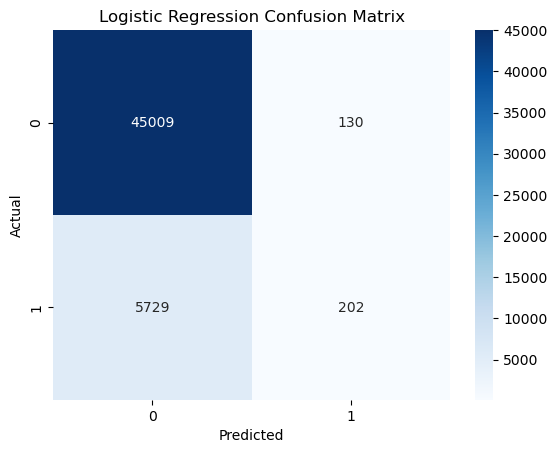

In [73]:
cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

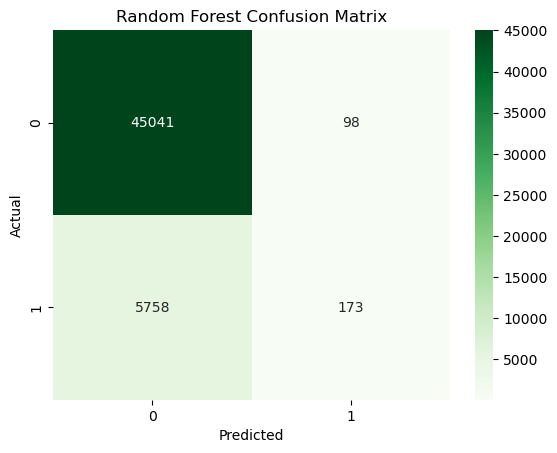

In [74]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [75]:
results = pd.DataFrame({
    'Model': ['Logistic Regression',
              'Decision Tree',
              'Random Forest'],
    
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.885275
1        Decision Tree  0.884883
2        Random Forest  0.885334
